In [315]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [308]:
import warnings

warnings.filterwarnings('ignore')

In [309]:
# Import dataset
data = 'weather.csv'

df = pd.read_csv(data)

In [310]:
# view dimensions of dataset

df.shape

(25000, 25)

In [204]:
#We can see that there are 25000 instances and 25 variables in the data set.

In [311]:
# preview the dataset

df.head()


,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


In [312]:
col_names = df.columns

col_names

Index(['Unnamed: 0', 'Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall',
       'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am',
       'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'RainToday', 'RISK_MM', 'RainTomorrow'],
      dtype='object')

In [313]:
#Drop RISK_MM variable
#It is given in the dataset description, that we should drop the RISK_MM feature variable from the dataset description. So, we should drop it as follows-
df.drop(['RISK_MM'], axis=1, inplace=True)

In [316]:
# view summary of dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     25000 non-null  int64  
 1   Date           25000 non-null  object 
 2   Location       25000 non-null  object 
 3   MinTemp        24669 non-null  float64
 4   MaxTemp        24824 non-null  float64
 5   Rainfall       24721 non-null  float64
 6   Evaporation    9432 non-null   float64
 7   Sunshine       6664 non-null   float64
 8   WindGustDir    21543 non-null  object 
 9   WindGustSpeed  21545 non-null  float64
 10  WindDir9am     21928 non-null  object 
 11  WindDir3pm     23267 non-null  object 
 12  WindSpeed9am   24428 non-null  float64
 13  WindSpeed3pm   23770 non-null  float64
 14  Humidity9am    24609 non-null  float64
 15  Humidity3pm    23936 non-null  float64
 16  Pressure9am    20172 non-null  float64
 17  Pressure3pm    20173 non-null  float64
 18  Cloud9

In [317]:
# find categorical variables
#Types of variables
#In this section, I segregate the dataset into categorical and numerical variables. There are a mixture of categorical and numerical variables in the dataset. Categorical variables have data type object. Numerical variables have data type float64.

#First of all, I will find categorical variables.
categorical = [var for var in df.columns if df[var].dtype=='O']

print('There are {} categorical variables\n'.format(len(categorical)))

print('The categorical variables are :', categorical)

There are 7 categorical variables

The categorical variables are : ['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']


In [318]:
#Summary of categorical variables
#There is a date variable. It is denoted by Date column.

#There are 6 categorical variables. These are given by Location, WindGustDir, WindDir9am, WindDir3pm, RainToday and RainTomorrow.

#There are two binary categorical variables - RainToday and RainTomorrow.

#RainTomorrow is the target variable.

In [319]:
# view the categorical variables
#Explore problems within categorical variables
#First, I will explore the categorical variables.

#Missing values in categorical variables

df[categorical].head()

,Date,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,W,W,WNW,No,No
1,2008-12-02,Albury,WNW,NNW,WSW,No,No
2,2008-12-03,Albury,WSW,W,WSW,No,No
3,2008-12-04,Albury,NE,SE,E,No,No
4,2008-12-05,Albury,W,ENE,NW,No,No


In [320]:
# check missing values in categorical variables

df[categorical].isnull().sum()

Date               0
Location           0
WindGustDir     3457
WindDir9am      3072
WindDir3pm      1733
RainToday        279
RainTomorrow       0
dtype: int64

In [321]:
# print categorical variables containing missing values

cat1 = [var for var in categorical if df[var].isnull().sum()!=0]

print(df[cat1].isnull().sum())

WindGustDir    3457
WindDir9am     3072
WindDir3pm     1733
RainToday       279
dtype: int64


In [322]:
#We can see that there are only 4 categorical variables in the dataset which contains missing values. These are WindGustDir, WindDir9am, WindDir3pm and RainToday.

In [323]:
#Frequency counts of categorical variables
#Now, I will check the frequency counts of categorical variables.
for var in categorical: 
    
    print(df[var].value_counts())

2011-10-11    9
2011-08-16    9
2011-08-24    9
2011-08-23    9
2011-08-22    9
             ..
2008-12-28    3
2008-12-29    3
2008-12-30    3
2008-12-10    2
2008-12-15    2
Name: Date, Length: 3040, dtype: int64
Albury           3011
Cobar            2988
NorfolkIsland    2964
Newcastle        2955
CoffsHarbour     2953
NorahHead        2929
BadgerysCreek    2928
Moree            2854
Penrith          1418
Name: Location, dtype: int64
NNE    1903
SW     1838
NE     1759
E      1590
WSW    1556
S      1553
SSW    1536
ENE    1436
W      1391
SSE    1213
SE     1192
WNW    1144
ESE    1058
N      1049
NW      740
NNW     585
Name: WindGustDir, dtype: int64
SW     2298
SE     1667
NNE    1612
NE     1604
N      1545
NW     1480
E      1478
SSW    1429
WSW    1398
S      1301
ESE    1148
ENE    1142
SSE    1137
W       976
NNW     878
WNW     835
Name: WindDir9am, dtype: int64
SE     2486
NE     2201
S      1710
SW     1573
E      1505
NNE    1495
SSE    1447
ESE    1384
W      1336
SSW

In [324]:
# view frequency distribution of categorical variables

for var in categorical: 
    
    print(df[var].value_counts()/np.float(len(df)))

2011-10-11    0.00036
2011-08-16    0.00036
2011-08-24    0.00036
2011-08-23    0.00036
2011-08-22    0.00036
               ...   
2008-12-28    0.00012
2008-12-29    0.00012
2008-12-30    0.00012
2008-12-10    0.00008
2008-12-15    0.00008
Name: Date, Length: 3040, dtype: float64
Albury           0.12044
Cobar            0.11952
NorfolkIsland    0.11856
Newcastle        0.11820
CoffsHarbour     0.11812
NorahHead        0.11716
BadgerysCreek    0.11712
Moree            0.11416
Penrith          0.05672
Name: Location, dtype: float64
NNE    0.07612
SW     0.07352
NE     0.07036
E      0.06360
WSW    0.06224
S      0.06212
SSW    0.06144
ENE    0.05744
W      0.05564
SSE    0.04852
SE     0.04768
WNW    0.04576
ESE    0.04232
N      0.04196
NW     0.02960
NNW    0.02340
Name: WindGustDir, dtype: float64
SW     0.09192
SE     0.06668
NNE    0.06448
NE     0.06416
N      0.06180
NW     0.05920
E      0.05912
SSW    0.05716
WSW    0.05592
S      0.05204
ESE    0.04592
ENE    0.04568
SSE    

In [325]:
# check for cardinality in categorical variables
#Number of labels: cardinality
#The number of labels within a categorical variable is known as cardinality. A high number of labels within a variable is known as high cardinality. High cardinality may pose some serious problems in the machine learning model. So, I will check for high cardinality.

for var in categorical:
    
    print(var, ' contains ', len(df[var].unique()), ' labels')

Date  contains  3040  labels
Location  contains  9  labels
WindGustDir  contains  17  labels
WindDir9am  contains  17  labels
WindDir3pm  contains  17  labels
RainToday  contains  3  labels
RainTomorrow  contains  2  labels


In [326]:
#We can see that there is a Date variable which needs to be preprocessed. I will do preprocessing in the following section.

#All the other variables contain relatively smaller number of variables.

#Feature Engineering of Date Variable
df['Date'].dtypes

dtype('O')

In [327]:
# parse the dates, currently coded as strings, into datetime format
#We can see that the data type of Date variable is object. I will parse the date currently coded as object into datetime format.

df['Date'] = pd.to_datetime(df['Date'])

In [328]:
# extract year from date

df['Year'] = df['Date'].dt.year

df['Year'].head()

0    2008
1    2008
2    2008
3    2008
4    2008
Name: Year, dtype: int64

In [329]:
# extract month from date

df['Month'] = df['Date'].dt.month

df['Month'].head()

0    12
1    12
2    12
3    12
4    12
Name: Month, dtype: int64

In [330]:
# extract day from date

df['Day'] = df['Date'].dt.day

df['Day'].head()

0    1
1    2
2    3
3    4
4    5
Name: Day, dtype: int64

In [331]:
# again view the summary of dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Unnamed: 0     25000 non-null  int64         
 1   Date           25000 non-null  datetime64[ns]
 2   Location       25000 non-null  object        
 3   MinTemp        24669 non-null  float64       
 4   MaxTemp        24824 non-null  float64       
 5   Rainfall       24721 non-null  float64       
 6   Evaporation    9432 non-null   float64       
 7   Sunshine       6664 non-null   float64       
 8   WindGustDir    21543 non-null  object        
 9   WindGustSpeed  21545 non-null  float64       
 10  WindDir9am     21928 non-null  object        
 11  WindDir3pm     23267 non-null  object        
 12  WindSpeed9am   24428 non-null  float64       
 13  WindSpeed3pm   23770 non-null  float64       
 14  Humidity9am    24609 non-null  float64       
 15  Humidity3pm    2393

In [332]:
#We can see that there are three additional columns created from Date variable. Now, I will drop the original Date variable from the dataset.

In [333]:
# drop the original Date variable

df.drop('Date', axis=1, inplace = True)

In [334]:
# preview the dataset again

df.head()

,Unnamed: 0,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day
0,0,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,1007.1,8.0,NaN,16.9,21.8,No,No,2008,12,1
1,1,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,1007.8,NaN,NaN,17.2,24.3,No,No,2008,12,2
2,2,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,1008.7,NaN,2.0,21.0,23.2,No,No,2008,12,3
3,3,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,1012.8,NaN,NaN,18.1,26.5,No,No,2008,12,4
4,4,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,1006.0,7.0,8.0,17.8,29.7,No,No,2008,12,5


In [227]:
#Now, we can see that the Date variable has been removed from the dataset.

In [335]:
# find categorical variables

categorical = [var for var in df.columns if df[var].dtype=='O']

print('There are {} categorical variables\n'.format(len(categorical)))

print('The categorical variables are :', categorical)

There are 6 categorical variables

The categorical variables are : ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']


In [229]:
#We can see that there are 6 categorical variables in the dataset. The Date variable has been removed. First, I will check missing values in categorical variables.

In [336]:
# check for missing values in categorical variables 

df[categorical].isnull().sum()

Location           0
WindGustDir     3457
WindDir9am      3072
WindDir3pm      1733
RainToday        279
RainTomorrow       0
dtype: int64

In [231]:
#We can see that WindGustDir, WindDir9am, WindDir3pm, RainToday variables contain missing values. I will explore these variables one by one.

In [337]:
# print number of labels in Location variable
#Explore Location variable

print('Location contains', len(df.Location.unique()), 'labels')

Location contains 9 labels


In [338]:
# check labels in location variable

df.Location.unique()

array(['Albury', 'BadgerysCreek', 'Cobar', 'CoffsHarbour', 'Moree',
       'Newcastle', 'NorahHead', 'NorfolkIsland', 'Penrith'], dtype=object)

In [339]:
# check frequency distribution of values in Location variable

df.Location.value_counts()

Albury           3011
Cobar            2988
NorfolkIsland    2964
Newcastle        2955
CoffsHarbour     2953
NorahHead        2929
BadgerysCreek    2928
Moree            2854
Penrith          1418
Name: Location, dtype: int64

In [340]:
# let's do One Hot Encoding of Location variable
# get k-1 dummy variables after One Hot Encoding 
# preview the dataset with head() method

pd.get_dummies(df.Location, drop_first=True).head()

,BadgerysCreek,Cobar,CoffsHarbour,Moree,Newcastle,NorahHead,NorfolkIsland,Penrith
0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0


In [341]:
# print number of labels in WindGustDir variable
#Explore WindGustDir variable

print('WindGustDir contains', len(df['WindGustDir'].unique()), 'labels')

WindGustDir contains 17 labels


In [342]:
# check labels in WindGustDir variable

df['WindGustDir'].unique()

array(['W', 'WNW', 'WSW', 'NE', 'NNW', 'N', 'NNE', 'SW', 'ENE', 'SSE',
       'S', 'NW', 'SE', 'ESE', nan, 'E', 'SSW'], dtype=object)

In [343]:
# check frequency distribution of values in WindGustDir variable

df.WindGustDir.value_counts()

NNE    1903
SW     1838
NE     1759
E      1590
WSW    1556
S      1553
SSW    1536
ENE    1436
W      1391
SSE    1213
SE     1192
WNW    1144
ESE    1058
N      1049
NW      740
NNW     585
Name: WindGustDir, dtype: int64

In [344]:
# check frequency distribution of values in WindGustDir variable

df.WindGustDir.value_counts()

NNE    1903
SW     1838
NE     1759
E      1590
WSW    1556
S      1553
SSW    1536
ENE    1436
W      1391
SSE    1213
SE     1192
WNW    1144
ESE    1058
N      1049
NW      740
NNW     585
Name: WindGustDir, dtype: int64

In [345]:
# sum the number of 1s per boolean variable over the rows of the dataset
# it will tell us how many observations we have for each category
# let's do One Hot Encoding of WindGustDir variable
# get k-1 dummy variables after One Hot Encoding 
# also add an additional dummy variable to indicate there was missing data
# preview the dataset with head() method


pd.get_dummies(df.WindGustDir, drop_first=True, dummy_na=True).sum(axis=0)

ENE    1436
ESE    1058
N      1049
NE     1759
NNE    1903
NNW     585
NW      740
S      1553
SE     1192
SSE    1213
SSW    1536
SW     1838
W      1391
WNW    1144
WSW    1556
NaN    3457
dtype: int64

In [346]:
# print number of labels in WindDir9am variable

print('WindDir9am contains', len(df['WindDir9am'].unique()), 'labels')

WindDir9am contains 17 labels


In [347]:
# check labels in WindDir9am variable

df['WindDir9am'].unique()

array(['W', 'NNW', 'SE', 'ENE', 'SW', 'SSE', 'S', 'NE', nan, 'SSW', 'N',
       'WSW', 'ESE', 'E', 'NW', 'WNW', 'NNE'], dtype=object)

In [348]:
# check frequency distribution of values in WindDir9am variable

df['WindDir9am'].value_counts()

SW     2298
SE     1667
NNE    1612
NE     1604
N      1545
NW     1480
E      1478
SSW    1429
WSW    1398
S      1301
ESE    1148
ENE    1142
SSE    1137
W       976
NNW     878
WNW     835
Name: WindDir9am, dtype: int64

In [349]:
# let's do One Hot Encoding of WindDir9am variable
# get k-1 dummy variables after One Hot Encoding 
# also add an additional dummy variable to indicate there was missing data
# preview the dataset with head() method

pd.get_dummies(df.WindDir9am, drop_first=True, dummy_na=True).head()

,ENE,ESE,N,NE,NNE,NNW,NW,S,SE,SSE,SSW,SW,W,WNW,WSW,NaN
0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [350]:
# sum the number of 1s per boolean variable over the rows of the dataset
# it will tell us how many observations we have for each category

pd.get_dummies(df.WindDir9am, drop_first=True, dummy_na=True).sum(axis=0)

ENE    1142
ESE    1148
N      1545
NE     1604
NNE    1612
NNW     878
NW     1480
S      1301
SE     1667
SSE    1137
SSW    1429
SW     2298
W       976
WNW     835
WSW    1398
NaN    3072
dtype: int64

In [351]:
# print number of labels in WindDir3pm variable

print('WindDir3pm contains', len(df['WindDir3pm'].unique()), 'labels')

WindDir3pm contains 17 labels


In [352]:
# check labels in WindDir3pm variable

df['WindDir3pm'].unique()

array(['WNW', 'WSW', 'E', 'NW', 'W', 'SSE', 'ESE', 'ENE', 'NNW', 'SSW',
       'SW', 'SE', 'N', 'S', 'NNE', nan, 'NE'], dtype=object)

In [353]:
# check frequency distribution of values in WindDir3pm variable

df['WindDir3pm'].value_counts()

SE     2486
NE     2201
S      1710
SW     1573
E      1505
NNE    1495
SSE    1447
ESE    1384
W      1336
SSW    1324
WSW    1285
ENE    1256
N      1214
NW     1206
WNW    1153
NNW     692
Name: WindDir3pm, dtype: int64

In [354]:
# let's do One Hot Encoding of WindDir3pm variable
# get k-1 dummy variables after One Hot Encoding 
# also add an additional dummy variable to indicate there was missing data
# preview the dataset with head() method

pd.get_dummies(df.WindDir3pm, drop_first=True, dummy_na=True).head()

,ENE,ESE,N,NE,NNE,NNW,NW,S,SE,SSE,SSW,SW,W,WNW,WSW,NaN
0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0


In [355]:
# sum the number of 1s per boolean variable over the rows of the dataset
# it will tell us how many observations we have for each category

pd.get_dummies(df.WindDir3pm, drop_first=True, dummy_na=True).sum(axis=0)

ENE    1256
ESE    1384
N      1214
NE     2201
NNE    1495
NNW     692
NW     1206
S      1710
SE     2486
SSE    1447
SSW    1324
SW     1573
W      1336
WNW    1153
WSW    1285
NaN    1733
dtype: int64

In [356]:
# print number of labels in RainToday variable

print('RainToday contains', len(df['RainToday'].unique()), 'labels')

RainToday contains 3 labels


In [357]:
# check labels in WindGustDir variable

df['RainToday'].unique()

array(['No', 'Yes', nan], dtype=object)

In [358]:
# check frequency distribution of values in WindGustDir variable

df.RainToday.value_counts()

No     19197
Yes     5524
Name: RainToday, dtype: int64

In [359]:
# let's do One Hot Encoding of RainToday variable
# get k-1 dummy variables after One Hot Encoding 
# also add an additional dummy variable to indicate there was missing data
# preview the dataset with head() method

pd.get_dummies(df.RainToday, drop_first=True, dummy_na=True).head()

,Yes,NaN
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


In [360]:
# sum the number of 1s per boolean variable over the rows of the dataset
# it will tell us how many observations we have for each category

pd.get_dummies(df.RainToday, drop_first=True, dummy_na=True).sum(axis=0)

Yes    5524
NaN     279
dtype: int64

In [361]:
# find numerical variables

numerical = [var for var in df.columns if df[var].dtype!='O']

print('There are {} numerical variables\n'.format(len(numerical)))

print('The numerical variables are :', numerical)

There are 20 numerical variables

The numerical variables are : ['Unnamed: 0', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'Year', 'Month', 'Day']


In [362]:
# view the numerical variables

df[numerical].head()

,Unnamed: 0,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Year,Month,Day
0,0,13.4,22.9,0.6,NaN,NaN,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,2008,12,1
1,1,7.4,25.1,0.0,NaN,NaN,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,2008,12,2
2,2,12.9,25.7,0.0,NaN,NaN,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,2008,12,3
3,3,9.2,28.0,0.0,NaN,NaN,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,2008,12,4
4,4,17.5,32.3,1.0,NaN,NaN,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,2008,12,5


In [363]:
# check missing values in numerical variables

df[numerical].isnull().sum()

Unnamed: 0           0
MinTemp            331
MaxTemp            176
Rainfall           279
Evaporation      15568
Sunshine         18336
WindGustSpeed     3455
WindSpeed9am       572
WindSpeed3pm      1230
Humidity9am        391
Humidity3pm       1064
Pressure9am       4828
Pressure3pm       4827
Cloud9am         10864
Cloud3pm         11185
Temp9am            245
Temp3pm            918
Year                 0
Month                0
Day                  0
dtype: int64

In [364]:
# view summary statistics in numerical variables

print(round(df[numerical].describe()),2)

       Unnamed: 0  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
count     25000.0  24669.0  24824.0   24721.0       9432.0    6664.0   
mean      12500.0     13.0     24.0       3.0          6.0       8.0   
std        7217.0      6.0      6.0      10.0          5.0       4.0   
min           0.0     -3.0      7.0       0.0          0.0       0.0   
25%        6250.0      9.0     20.0       0.0          3.0       6.0   
50%       12500.0     14.0     23.0       0.0          5.0       9.0   
75%       18749.0     18.0     28.0       1.0          7.0      11.0   
max       24999.0     30.0     47.0     371.0         86.0      14.0   

       WindGustSpeed  WindSpeed9am  WindSpeed3pm  Humidity9am  Humidity3pm  \
count        21545.0       24428.0       23770.0      24609.0      23936.0   
mean            38.0          13.0          17.0         70.0         53.0   
std             13.0           9.0           9.0         18.0         21.0   
min              7.0           0.0     

Text(0, 0.5, 'WindSpeed3pm')

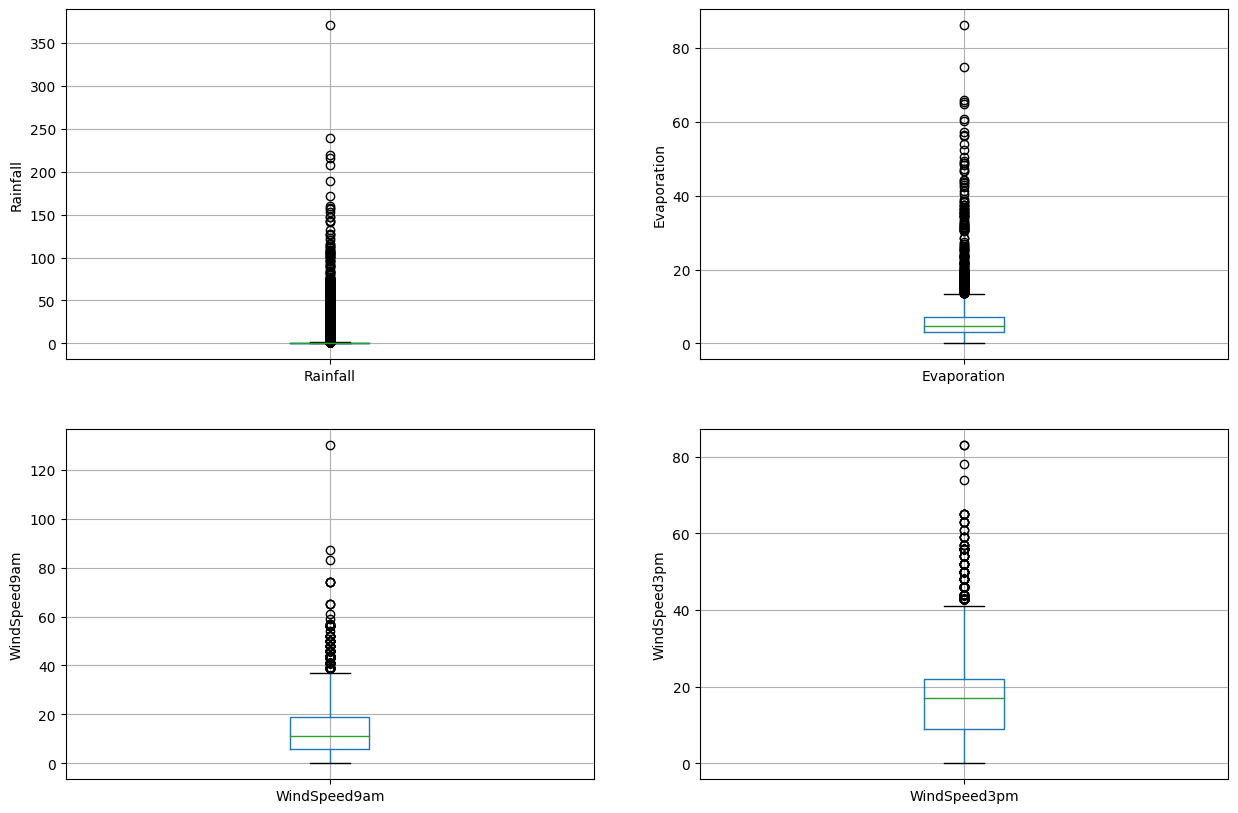

In [365]:
# draw boxplots to visualize outliers

plt.figure(figsize=(15,10))


plt.subplot(2, 2, 1)
fig = df.boxplot(column='Rainfall')
fig.set_title('')
fig.set_ylabel('Rainfall')


plt.subplot(2, 2, 2)
fig = df.boxplot(column='Evaporation')
fig.set_title('')
fig.set_ylabel('Evaporation')


plt.subplot(2, 2, 3)
fig = df.boxplot(column='WindSpeed9am')
fig.set_title('')
fig.set_ylabel('WindSpeed9am')


plt.subplot(2, 2, 4)
fig = df.boxplot(column='WindSpeed3pm')
fig.set_title('')
fig.set_ylabel('WindSpeed3pm')

Text(0, 0.5, 'RainTomorrow')

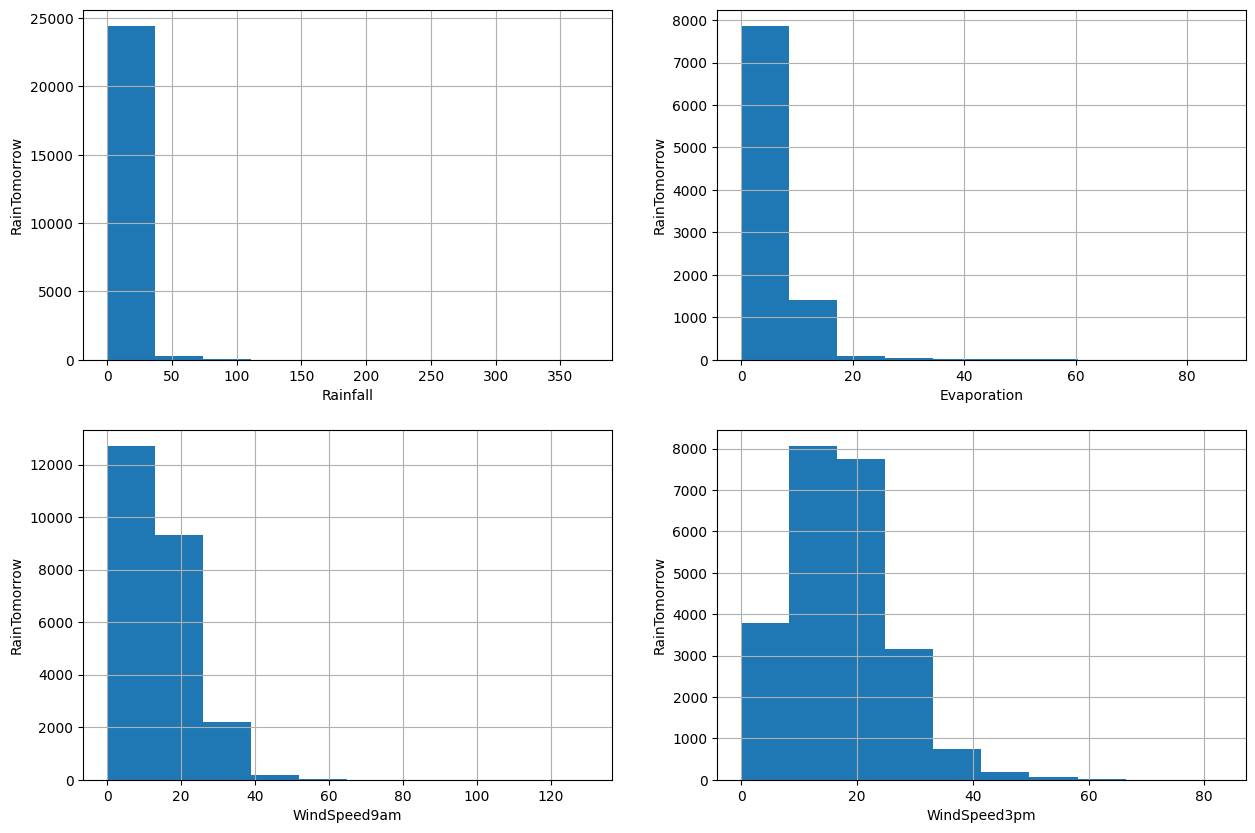

In [366]:
# plot histogram to check distribution

plt.figure(figsize=(15,10))


plt.subplot(2, 2, 1)
fig = df.Rainfall.hist(bins=10)
fig.set_xlabel('Rainfall')
fig.set_ylabel('RainTomorrow')


plt.subplot(2, 2, 2)
fig = df.Evaporation.hist(bins=10)
fig.set_xlabel('Evaporation')
fig.set_ylabel('RainTomorrow')


plt.subplot(2, 2, 3)
fig = df.WindSpeed9am.hist(bins=10)
fig.set_xlabel('WindSpeed9am')
fig.set_ylabel('RainTomorrow')


plt.subplot(2, 2, 4)
fig = df.WindSpeed3pm.hist(bins=10)
fig.set_xlabel('WindSpeed3pm')
fig.set_ylabel('RainTomorrow')

In [367]:
# find outliers for Rainfall variable

IQR = df.Rainfall.quantile(0.75) - df.Rainfall.quantile(0.25)
Lower_fence = df.Rainfall.quantile(0.25) - (IQR * 3)
Upper_fence = df.Rainfall.quantile(0.75) + (IQR * 3)
print('Rainfall outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=Lower_fence, upperboundary=Upper_fence))

Rainfall outliers are values < -1.7999999999999998 or > 2.4


In [368]:
# find outliers for Evaporation variable

IQR = df.Evaporation.quantile(0.75) - df.Evaporation.quantile(0.25)
Lower_fence = df.Evaporation.quantile(0.25) - (IQR * 3)
Upper_fence = df.Evaporation.quantile(0.75) + (IQR * 3)
print('Evaporation outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=Lower_fence, upperboundary=Upper_fence))

Evaporation outliers are values < -9.600000000000001 or > 19.8


In [369]:
# find outliers for WindSpeed9am variable

IQR = df.WindSpeed9am.quantile(0.75) - df.WindSpeed9am.quantile(0.25)
Lower_fence = df.WindSpeed9am.quantile(0.25) - (IQR * 3)
Upper_fence = df.WindSpeed9am.quantile(0.75) + (IQR * 3)
print('WindSpeed9am outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=Lower_fence, upperboundary=Upper_fence))

WindSpeed9am outliers are values < -33.0 or > 58.0


In [370]:
# find outliers for WindSpeed3pm variable

IQR = df.WindSpeed3pm.quantile(0.75) - df.WindSpeed3pm.quantile(0.25)
Lower_fence = df.WindSpeed3pm.quantile(0.25) - (IQR * 3)
Upper_fence = df.WindSpeed3pm.quantile(0.75) + (IQR * 3)
print('WindSpeed3pm outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=Lower_fence, upperboundary=Upper_fence))

WindSpeed3pm outliers are values < -30.0 or > 61.0


In [371]:
X = df.drop(['RainTomorrow'], axis=1)

y = df['RainTomorrow']

In [372]:
# split X and y into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [373]:
# check the shape of X_train and X_test

X_train.shape, X_test.shape

((20000, 25), (5000, 25))

In [374]:
# check data types in X_train

X_train.dtypes

Unnamed: 0         int64
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
Year               int64
Month              int64
Day                int64
dtype: object

In [375]:
# display categorical variables

categorical = [col for col in X_train.columns if X_train[col].dtypes == 'O']

categorical

['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

In [376]:
# display numerical variables

numerical = [col for col in X_train.columns if X_train[col].dtypes != 'O']

numerical

['Unnamed: 0',
 'MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustSpeed',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm',
 'Year',
 'Month',
 'Day']

In [377]:
# check missing values in numerical variables in X_train

X_train[numerical].isnull().sum()

Unnamed: 0           0
MinTemp            268
MaxTemp            145
Rainfall           226
Evaporation      12485
Sunshine         14673
WindGustSpeed     2743
WindSpeed9am       455
WindSpeed3pm       983
Humidity9am        303
Humidity3pm        850
Pressure9am       3846
Pressure3pm       3847
Cloud9am          8723
Cloud3pm          8987
Temp9am            194
Temp3pm            736
Year                 0
Month                0
Day                  0
dtype: int64

In [378]:
# check missing values in numerical variables in X_test

X_test[numerical].isnull().sum()

Unnamed: 0          0
MinTemp            63
MaxTemp            31
Rainfall           53
Evaporation      3083
Sunshine         3663
WindGustSpeed     712
WindSpeed9am      117
WindSpeed3pm      247
Humidity9am        88
Humidity3pm       214
Pressure9am       982
Pressure3pm       980
Cloud9am         2141
Cloud3pm         2198
Temp9am            51
Temp3pm           182
Year                0
Month               0
Day                 0
dtype: int64

In [379]:
# print percentage of missing values in the numerical variables in training set

for col in numerical:
    if X_train[col].isnull().mean()>0:
        print(col, round(X_train[col].isnull().mean(),4))

MinTemp 0.0134
MaxTemp 0.0072
Rainfall 0.0113
Evaporation 0.6242
Sunshine 0.7336
WindGustSpeed 0.1372
WindSpeed9am 0.0228
WindSpeed3pm 0.0492
Humidity9am 0.0152
Humidity3pm 0.0425
Pressure9am 0.1923
Pressure3pm 0.1924
Cloud9am 0.4362
Cloud3pm 0.4494
Temp9am 0.0097
Temp3pm 0.0368


In [380]:
# impute missing values in X_train and X_test with respective column median in X_train

for df1 in [X_train, X_test]:
    for col in numerical:
        col_median=X_train[col].median()
        df1[col].fillna(col_median, inplace=True)           

In [381]:
# check again missing values in numerical variables in X_train

X_train[numerical].isnull().sum()

Unnamed: 0       0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustSpeed    0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
Year             0
Month            0
Day              0
dtype: int64

In [382]:
# check missing values in numerical variables in X_test

X_test[numerical].isnull().sum()


Unnamed: 0       0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustSpeed    0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
Year             0
Month            0
Day              0
dtype: int64

In [383]:
# print percentage of missing values in the categorical variables in training set

X_train[categorical].isnull().mean()

Location       0.00000
WindGustDir    0.13725
WindDir9am     0.12260
WindDir3pm     0.06865
RainToday      0.01130
dtype: float64

In [384]:
# print categorical variables with missing data

for col in categorical:
    if X_train[col].isnull().mean()>0:
        print(col, (X_train[col].isnull().mean()))

WindGustDir 0.13725
WindDir9am 0.1226
WindDir3pm 0.06865
RainToday 0.0113


In [385]:
# impute missing categorical variables with most frequent value

for df2 in [X_train, X_test]:
    df2['WindGustDir'].fillna(X_train['WindGustDir'].mode()[0], inplace=True)
    df2['WindDir9am'].fillna(X_train['WindDir9am'].mode()[0], inplace=True)
    df2['WindDir3pm'].fillna(X_train['WindDir3pm'].mode()[0], inplace=True)
    df2['RainToday'].fillna(X_train['RainToday'].mode()[0], inplace=True)

In [386]:
# check missing values in categorical variables in X_train

X_train[categorical].isnull().sum()

Location       0
WindGustDir    0
WindDir9am     0
WindDir3pm     0
RainToday      0
dtype: int64

In [387]:
# check missing values in X_train

X_train.isnull().sum()

Unnamed: 0       0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
Year             0
Month            0
Day              0
dtype: int64

In [388]:
# check missing values in X_test

X_test.isnull().sum()

Unnamed: 0       0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
Year             0
Month            0
Day              0
dtype: int64

In [389]:
def max_value(df3, variable, top):
    return np.where(df3[variable]>top, top, df3[variable])

for df3 in [X_train, X_test]:
    df3['Rainfall'] = max_value(df3, 'Rainfall', 3.2)
    df3['Evaporation'] = max_value(df3, 'Evaporation', 21.8)
    df3['WindSpeed9am'] = max_value(df3, 'WindSpeed9am', 55)
    df3['WindSpeed3pm'] = max_value(df3, 'WindSpeed3pm', 57)

In [390]:
X_train.Rainfall.max(), X_test.Rainfall.max()

(3.2, 3.2)

In [391]:
X_train.Evaporation.max(), X_test.Evaporation.max()

(21.8, 21.8)

In [287]:
X_train.WindSpeed9am.max(), X_test.WindSpeed9am.max()

(55.0, 55.0)

In [392]:
X_train.WindSpeed3pm.max(), X_test.WindSpeed3pm.max()

(57.0, 57.0)

In [393]:
X_train[numerical].describe()

,Unnamed: 0,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Year,Month,Day
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,12488.320300,13.308410,23.983970,0.679780,5.125575,8.616080,37.380600,12.622550,16.832750,69.891900,52.801950,1018.179080,1015.640470,4.583450,4.674550,17.953740,22.479675,2012.621900,6.381350,15.67930
std,7217.940007,5.822592,6.107935,1.193324,2.384973,1.971589,12.277043,8.967246,8.811785,17.598145,20.689834,5.818122,5.744435,2.260463,2.038907,5.384442,5.853304,2.494043,3.415846,8.80007
min,0.000000,-3.300000,6.800000,0.000000,0.000000,0.000000,7.000000,0.000000,0.000000,3.000000,1.000000,980.500000,979.000000,0.000000,0.000000,0.300000,6.400000,2008.000000,1.000000,1.00000
25%,6249.750000,9.000000,19.500000,0.000000,4.800000,8.900000,30.000000,6.000000,11.000000,58.000000,37.000000,1015.000000,1012.500000,4.000000,4.000000,14.300000,18.200000,2010.000000,3.000000,8.00000
50%,12495.500000,14.100000,23.400000,0.000000,4.800000,8.900000,35.000000,11.000000,17.000000,71.000000,54.000000,1018.200000,1015.700000,5.000000,5.000000,18.400000,21.800000,2013.000000,6.000000,16.00000
75%,18752.250000,17.900000,27.700000,0.600000,4.800000,8.900000,44.000000,19.000000,22.000000,83.000000,67.000000,1021.400000,1018.900000,6.000000,5.000000,21.900000,25.900000,2015.000000,9.000000,23.00000
max,24998.000000,29.400000,47.300000,3.200000,21.800000,14.000000,135.000000,55.000000,57.000000,100.000000,100.000000,1039.900000,1036.800000,8.000000,8.000000,37.700000,46.700000,2017.000000,12.000000,31.00000


In [394]:
categorical

['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

In [395]:
X_train[categorical].head()

,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday
10263,CoffsHarbour,S,S,ESE,No
18409,NorahHead,SSE,SSE,SSE,No
13047,Moree,E,E,ESE,No
21371,NorfolkIsland,ESE,SE,SE,No
16392,Newcastle,NNE,SW,SE,No


In [396]:
# encode RainToday variable

import category_encoders as ce

encoder = ce.BinaryEncoder(cols=['RainToday'])

X_train = encoder.fit_transform(X_train)

X_test = encoder.transform(X_test)

In [397]:
X_train.head()

,Unnamed: 0,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday_0,RainToday_1,Year,Month,Day
10263,10263,CoffsHarbour,15.5,19.5,0.0,5.0,9.9,S,33.0,S,...,1018.4,3.0,1.0,17.4,18.2,0,1,2012,9,30
18409,18409,NorahHead,22.5,25.6,0.4,4.8,8.9,SSE,52.0,SSE,...,1019.0,5.0,5.0,24.1,24.0,0,1,2011,1,28
13047,13047,Moree,12.8,25.7,0.0,3.2,9.1,E,24.0,E,...,1013.5,5.0,6.0,18.9,25.3,0,1,2012,4,18
21371,21371,NorfolkIsland,19.0,24.1,0.2,6.4,9.2,ESE,35.0,SE,...,1010.0,6.0,7.0,21.4,22.6,0,1,2011,1,24
16392,16392,Newcastle,10.6,27.2,0.0,4.8,8.9,NNE,35.0,SW,...,1015.7,8.0,3.0,18.4,24.5,0,1,2013,10,28


In [398]:
X_train = pd.concat([X_train[numerical], X_train[['RainToday_0', 'RainToday_1']],
                     pd.get_dummies(X_train.Location), 
                     pd.get_dummies(X_train.WindGustDir),
                     pd.get_dummies(X_train.WindDir9am),
                     pd.get_dummies(X_train.WindDir3pm)], axis=1)

In [399]:
X_train.head()

,Unnamed: 0,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,...,NNW,NW,S,SE,SSE,SSW,SW,W,WNW,WSW
10263,10263,15.5,19.5,0.0,5.0,9.9,33.0,24.0,15.0,45.0,...,0,0,0,0,0,0,0,0,0,0
18409,18409,22.5,25.6,0.4,4.8,8.9,52.0,35.0,30.0,69.0,...,0,0,0,0,1,0,0,0,0,0
13047,13047,12.8,25.7,0.0,3.2,9.1,24.0,11.0,13.0,78.0,...,0,0,0,0,0,0,0,0,0,0
21371,21371,19.0,24.1,0.2,6.4,9.2,35.0,19.0,20.0,74.0,...,0,0,0,1,0,0,0,0,0,0
16392,16392,10.6,27.2,0.0,4.8,8.9,35.0,0.0,9.0,77.0,...,0,0,0,1,0,0,0,0,0,0


In [400]:
#Similarly, I will create the X_test testing set.

X_test = pd.concat([X_test[numerical], X_test[['RainToday_0', 'RainToday_1']],
                     pd.get_dummies(X_test.Location), 
                     pd.get_dummies(X_test.WindGustDir),
                     pd.get_dummies(X_test.WindDir9am),
                     pd.get_dummies(X_test.WindDir3pm)], axis=1)

In [401]:
X_test.head()

,Unnamed: 0,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,...,NNW,NW,S,SE,SSE,SSW,SW,W,WNW,WSW
14149,14149,19.6,33.9,0.0,10.0,9.1,72.0,31.0,17.0,62.0,...,0,0,0,0,0,0,0,0,0,0
8946,8946,20.2,28.5,0.0,5.4,8.0,59.0,17.0,39.0,64.0,...,0,0,0,0,0,0,0,0,0,0
22378,22378,20.3,25.9,0.0,3.8,9.9,52.0,30.0,30.0,78.0,...,0,0,0,0,0,0,0,0,0,0
12162,12162,8.2,25.9,0.0,8.8,7.2,35.0,22.0,9.0,40.0,...,0,0,0,0,0,1,0,0,0,0
4879,4879,0.8,17.2,0.0,4.8,8.9,41.0,6.0,26.0,77.0,...,0,0,0,0,0,0,0,0,0,1


In [402]:
#We now have training and testing set ready for model building. Before that, we should map all the feature variables onto the same scale. It is called feature scaling. I will do it as follows.

#Feature Scaling
X_train.describe()

,Unnamed: 0,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,...,NNW,NW,S,SE,SSE,SSW,SW,W,WNW,WSW
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,12488.320300,13.308410,23.983970,0.679780,5.125575,8.616080,37.380600,12.622550,16.832750,69.891900,...,0.026800,0.049050,0.067100,0.167850,0.058700,0.052600,0.062400,0.053000,0.046850,0.052300
std,7217.940007,5.822592,6.107935,1.193324,2.384973,1.971589,12.277043,8.967246,8.811785,17.598145,...,0.161503,0.215978,0.250201,0.373742,0.235068,0.223239,0.241887,0.224039,0.211323,0.222637
min,0.000000,-3.300000,6.800000,0.000000,0.000000,0.000000,7.000000,0.000000,0.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6249.750000,9.000000,19.500000,0.000000,4.800000,8.900000,30.000000,6.000000,11.000000,58.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,12495.500000,14.100000,23.400000,0.000000,4.800000,8.900000,35.000000,11.000000,17.000000,71.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,18752.250000,17.900000,27.700000,0.600000,4.800000,8.900000,44.000000,19.000000,22.000000,83.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,24998.000000,29.400000,47.300000,3.200000,21.800000,14.000000,135.000000,55.000000,57.000000,100.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [403]:
cols = X_train.columns

In [404]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [405]:
X_train = pd.DataFrame(X_train, columns=[cols])

In [406]:
X_test = pd.DataFrame(X_test, columns=[cols])

In [407]:
X_train.describe()

,Unnamed: 0,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,...,NNW,NW,S,SE,SSE,SSW,SW,W,WNW,WSW
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,0.499573,0.507902,0.424296,0.212431,0.235118,0.615434,0.237348,0.229501,0.295311,0.689607,...,0.026800,0.049050,0.067100,0.167850,0.058700,0.052600,0.062400,0.053000,0.046850,0.052300
std,0.288741,0.178061,0.150813,0.372914,0.109402,0.140828,0.095914,0.163041,0.154593,0.181424,...,0.161503,0.215978,0.250201,0.373742,0.235068,0.223239,0.241887,0.224039,0.211323,0.222637
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.250010,0.376147,0.313580,0.000000,0.220183,0.635714,0.179688,0.109091,0.192982,0.567010,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.499860,0.532110,0.409877,0.000000,0.220183,0.635714,0.218750,0.200000,0.298246,0.701031,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.750150,0.648318,0.516049,0.187500,0.220183,0.635714,0.289062,0.345455,0.385965,0.824742,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [408]:
# train a logistic regression model on the training set
from sklearn.linear_model import LogisticRegression


# instantiate the model
logreg = LogisticRegression(solver='liblinear', random_state=0)


# fit the model
logreg.fit(X_train, y_train)

LogisticRegression(random_state=0, solver='liblinear')

In [409]:
#Predict results
y_pred_test = logreg.predict(X_test)

y_pred_test

array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype=object)

In [410]:
#Check accuracy score
from sklearn.metrics import accuracy_score

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred_test)))
#Here, y_test are the true class labels and y_pred_test are the predicted class labels in the test-set.

Model accuracy score: 0.8420


In [ ]:
#Compare the train-set and test-set accuracy
#Now, I will compare the train-set and test-set accuracy to check for overfitting.

In [411]:
#Compare the train-set and test-set accuracy

y_pred_train = logreg.predict(X_train)

y_pred_train

array(['No', 'No', 'No', ..., 'No', 'Yes', 'Yes'], dtype=object)

In [412]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train)))

Training-set accuracy score: 0.8448


In [413]:
#Check for overfitting and underfitting
# print the scores on training and test set

print('Training set score: {:.4f}'.format(logreg.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(logreg.score(X_test, y_test)))

Training set score: 0.8448
Test set score: 0.8420


In [114]:
#The training-set accuracy score is 0.8448 while the test-set accuracy to be 0.8501. These two values are quite comparable. So, there is no question of overfitting.

#In Logistic Regression, we use default value of C = 1. It provides good performance with approximately 85% accuracy on both the training and the test set. But the model performance on both the training and test set are very comparable. It is likely the case of underfitting.

#I will increase C and fit a more flexible model.

In [414]:
# fit the Logsitic Regression model with C=100

# instantiate the model
logreg100 = LogisticRegression(C=100, solver='liblinear', random_state=0)


# fit the model
logreg100.fit(X_train, y_train)

LogisticRegression(C=100, random_state=0, solver='liblinear')

In [415]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(logreg100.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(logreg100.score(X_test, y_test)))

Training set score: 0.8447
Test set score: 0.8446


In [117]:
#We can see that, C=100 results in higher test set accuracy and also a slightly increased training set accuracy. So, we can conclude that a more complex model should perform better.

#Now, I will investigate, what happens if we use more regularized model than the default value of C=1, by setting C=0.01.

In [416]:
# fit the Logsitic Regression model with C=001

# instantiate the model
logreg001 = LogisticRegression(C=0.01, solver='liblinear', random_state=0)


# fit the model
logreg001.fit(X_train, y_train)

LogisticRegression(C=0.01, random_state=0, solver='liblinear')

In [417]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(logreg001.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(logreg001.score(X_test, y_test)))

Training set score: 0.8258
Test set score: 0.8236


In [120]:
#So, if we use more regularized model by setting C=0.01, then both the training and test set accuracy decrease relatiev to the default parameters.

In [ ]:
#Compare model accuracy with null accuracy
#So, the model accuracy is 0.8501. But, we cannot say that our model is very good based on the above accuracy. We must compare it with the null accuracy. Null accuracy is the accuracy that could be achieved by always predicting the most frequent class.

#So, we should first check the class distribution in the test set.

In [418]:
# check class distribution in test set

y_test.value_counts()

No     3860
Yes    1140
Name: RainTomorrow, dtype: int64

In [419]:
#We can see that the occurences of most frequent class is 22067. So, we can calculate null accuracy by dividing 22067 by total number of occurences.
# check null accuracy score

null_accuracy = (22067/(22067+6372))

print('Null accuracy score: {0:0.4f}'. format(null_accuracy))

Null accuracy score: 0.7759


In [ ]:
#We can see that our model accuracy score is 0.8501 but null accuracy score is 0.7759. So, we can conclude that our Logistic Regression model is doing a very good job in predicting the class labels.

#Now, based on the above analysis we can conclude that our classification model accuracy is very good. Our model is doing a very good job in terms of predicting the class labels.

#But, it does not give the underlying distribution of values. Also, it does not tell anything about the type of errors our classifer is making.

#We have another tool called Confusion matrix that comes to our rescue.

In [420]:
#Confusion matrix
# Print the Confusion Matrix and slice it into four pieces

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

print('Confusion matrix\n\n', cm)

print('\nTrue Positives(TP) = ', cm[0,0])

print('\nTrue Negatives(TN) = ', cm[1,1])

print('\nFalse Positives(FP) = ', cm[0,1])

print('\nFalse Negatives(FN) = ', cm[1,0])

Confusion matrix

 [[3659  201]
 [ 589  551]]

True Positives(TP) =  3659

True Negatives(TN) =  551

False Positives(FP) =  201

False Negatives(FN) =  589


In [ ]:
#True Positives(TP) =  3659

#True Negatives(TN) =  551

#False Positives(FP) =  201    TypeI error

#False Negatives(FN) =  589    TypeII error

#The confusion matrix shows 3659 + 551 = 4210 correct predictions and 201 + 589 = 790 incorrect predictions.


<AxesSubplot:>

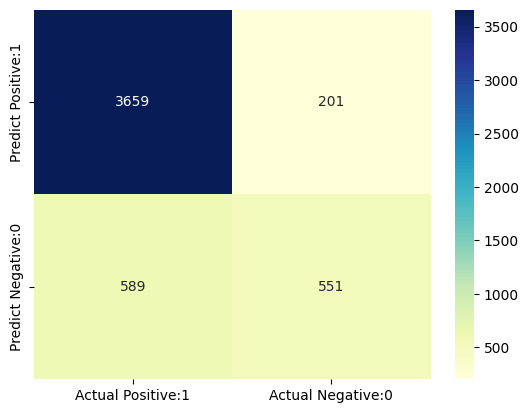

In [421]:
# visualize confusion matrix with seaborn heatmap

cm_matrix = pd.DataFrame(data=cm, columns=['Actual Positive:1', 'Actual Negative:0'], 
                                 index=['Predict Positive:1', 'Predict Negative:0'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')

In [ ]:
#Classification Report
#Classification report is another way to evaluate the classification model performance. It displays the precision, recall, f1 and support scores for the model. I have described these terms in later.

#We can print a classification report as follows:-

In [422]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

          No       0.86      0.95      0.90      3860
         Yes       0.73      0.48      0.58      1140

    accuracy                           0.84      5000
   macro avg       0.80      0.72      0.74      5000
weighted avg       0.83      0.84      0.83      5000



In [423]:
#Classification accuracy
TP = cm[0,0]
TN = cm[1,1]
FP = cm[0,1]
FN = cm[1,0]

In [424]:
# print classification accuracy

classification_accuracy = (TP + TN) / float(TP + TN + FP + FN)

print('Classification accuracy : {0:0.4f}'.format(classification_accuracy))

Classification accuracy : 0.8420


In [425]:
#Classification error
# print classification error

classification_error = (FP + FN) / float(TP + TN + FP + FN)

print('Classification error : {0:0.4f}'.format(classification_error))

Classification error : 0.1580


In [ ]:
#Precision can be defined as the percentage of correctly predicted positive outcomes out of all the predicted positive outcomes. It can be given as the ratio of true positives (TP) to the sum of true and false positives (TP + FP).

#So, Precision identifies the proportion of correctly predicted positive outcome. It is more concerned with the positive class than the negative class.

#Mathematically, precision can be defined as the ratio of TP to (TP + FP).

In [426]:
# print precision score

precision = TP / float(TP + FP)


print('Precision : {0:0.4f}'.format(precision))

Precision : 0.9479


In [ ]:
#Recall can be defined as the percentage of correctly predicted positive outcomes out of all the actual positive outcomes. It can be given as the ratio of true positives (TP) to the sum of true positives and false negatives (TP + FN). Recall is also called Sensitivity.

#Recall identifies the proportion of correctly predicted actual positives.

#Mathematically, recall can be given as the ratio of TP to (TP + FN).

In [427]:
recall = TP / float(TP + FN)

print('Recall or Sensitivity : {0:0.4f}'.format(recall))

Recall or Sensitivity : 0.8613


In [428]:
#True Positive Rate is synonymous with Recall.
true_positive_rate = TP / float(TP + FN)


print('True Positive Rate : {0:0.4f}'.format(true_positive_rate))

True Positive Rate : 0.8613


In [429]:
#False Positive Rate
false_positive_rate = FP / float(FP + TN)


print('False Positive Rate : {0:0.4f}'.format(false_positive_rate))

False Positive Rate : 0.2673


In [430]:
#Specificity
specificity = TN / (TN + FP)

print('Specificity : {0:0.4f}'.format(specificity))

Specificity : 0.7327


In [ ]:
#f1-score
#f1-score is the weighted harmonic mean of precision and recall. The best possible f1-score would be 1.0 and the worst would be 0.0. f1-score is the harmonic mean of precision and recall. So, f1-score is always lower than accuracy measures as they embed precision and recall into their computation. The weighted average of f1-score should be used to compare classifier models, not global accuracy.

In [431]:
#Adjusting the threshold level
# print the first 10 predicted probabilities of two classes- 0 and 1

y_pred_prob = logreg.predict_proba(X_test)[0:10]

y_pred_prob

array([[0.76925314, 0.23074686],
       [0.67590869, 0.32409131],
       [0.692837  , 0.307163  ],
       [0.97194928, 0.02805072],
       [0.95492153, 0.04507847],
       [0.99045147, 0.00954853],
       [0.34759111, 0.65240889],
       [0.78777377, 0.21222623],
       [0.878691  , 0.121309  ],
       [0.70132206, 0.29867794]])

In [ ]:
#Observations
#In each row, the numbers sum to 1.

#There are 2 columns which correspond to 2 classes - 0 and 1.

#Class 0 - predicted probability that there is no rain tomorrow.

#Class 1 - predicted probability that there is rain tomorrow.

#Importance of predicted probabilities

#We can rank the observations by probability of rain or no rain.
#predict_proba process

#Predicts the probabilities

#Choose the class with the highest probability

#Classification threshold level

#There is a classification threshold level of 0.5.

#Class 1 - probability of rain is predicted if probability > 0.5.

#Class 0 - probability of no rain is predicted if probability < 0.5.

In [ ]:
#predict_proba method
#predict_proba method gives the probabilities for the target variable(0 and 1) in this case, in array form.

#0 is for probability of no rain and 1 is for probability of rain.

In [432]:
# probability of getting output as 0 - no rain

logreg.predict_proba(X_test)[:,0]

array([0.76925314, 0.67590869, 0.692837  , ..., 0.97448253, 0.93430156,
       0.92248984])

In [433]:
# probability of getting output as 1 - rain

logreg.predict_proba(X_test)[:,1]

array([0.23074686, 0.32409131, 0.307163  , ..., 0.02551747, 0.06569844,
       0.07751016])

In [434]:
# store the probabilities in dataframe

y_pred_prob_df = pd.DataFrame(data=y_pred_prob, columns=['Prob of - No rain tomorrow (0)', 'Prob of - Rain tomorrow (1)'])

y_pred_prob_df

,Prob of - No rain tomorrow (0),Prob of - Rain tomorrow (1)
0,0.769253,0.230747
1,0.675909,0.324091
2,0.692837,0.307163
3,0.971949,0.028051
4,0.954922,0.045078
5,0.990451,0.009549
6,0.347591,0.652409
7,0.787774,0.212226
8,0.878691,0.121309
9,0.701322,0.298678


In [435]:
# print the first 10 predicted probabilities for class 1 - Probability of rain

logreg.predict_proba(X_test)[0:10, 1]

array([0.23074686, 0.32409131, 0.307163  , 0.02805072, 0.04507847,
       0.00954853, 0.65240889, 0.21222623, 0.121309  , 0.29867794])

In [436]:
# store the predicted probabilities for class 1 - Probability of rain

y_pred1 = logreg.predict_proba(X_test)[:, 1]

Text(0, 0.5, 'Frequency')

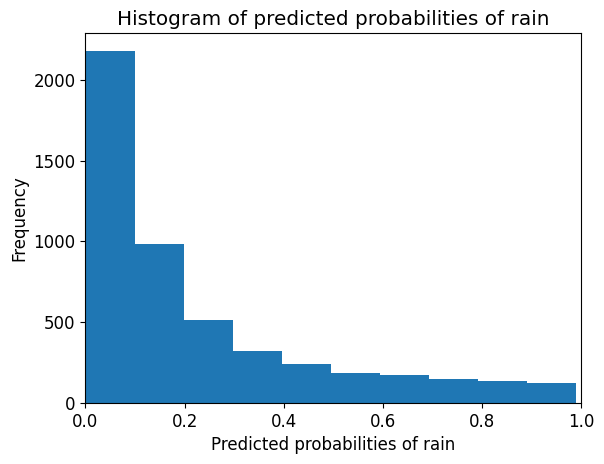

In [437]:
# plot histogram of predicted probabilities


# adjust the font size 
plt.rcParams['font.size'] = 12


# plot histogram with 10 bins
plt.hist(y_pred1, bins = 10)


# set the title of predicted probabilities
plt.title('Histogram of predicted probabilities of rain')


# set the x-axis limit
plt.xlim(0,1)


# set the title
plt.xlabel('Predicted probabilities of rain')
plt.ylabel('Frequency')

In [438]:
#Observations
#We can see that the above histogram is highly positive skewed.

#The first column tell us that there are approximately 15000 observations with probability between 0.0 and 0.1.

#There are small number of observations with probability > 0.5.

#So, these small number of observations predict that there will be rain tomorrow.

#Majority of observations predict that there will be no rain tomorrow.

In [445]:
#Lower the threshold
class MyClass:
        def binarize(self, data): # Correct: self is included
            # ...
            pass
obj = MyClass()
obj.binarize(y_pred1)
from sklearn.preprocessing import binarize

for i in range(1,5):
    
    cm1=0
    
    y_pred1 = logreg.predict_proba(X_test)[:,1]
    
    y_pred1 = y_pred1.reshape(-1,1)
    
    y_pred2 = binarize(y_pred1)
    
    y_pred2 = np.where(y_pred2 == 1, 'Yes', 'No')
    
    cm1 = confusion_matrix(y_test, y_pred2)
        
    print ('With',i/10,'threshold the Confusion Matrix is ','\n\n',cm1,'\n\n',
           
            'with',cm1[0,0]+cm1[1,1],'correct predictions, ', '\n\n', 
           
            cm1[0,1],'Type I errors( False Positives), ','\n\n',
           
            cm1[1,0],'Type II errors( False Negatives), ','\n\n',
           
           'Accuracy score: ', (accuracy_score(y_test, y_pred2)), '\n\n',
           
           'Sensitivity: ',cm1[1,1]/(float(cm1[1,1]+cm1[1,0])), '\n\n',
           
           'Specificity: ',cm1[0,0]/(float(cm1[0,0]+cm1[0,1])),'\n\n',
          
            '====================================================', '\n\n')

With 0.1 threshold the Confusion Matrix is  

 [[   0 3860]
 [   0 1140]] 

 with 1140 correct predictions,  

 3860 Type I errors( False Positives),  

 0 Type II errors( False Negatives),  

 Accuracy score:  0.228 

 Sensitivity:  1.0 

 Specificity:  0.0 



With 0.2 threshold the Confusion Matrix is  

 [[   0 3860]
 [   0 1140]] 

 with 1140 correct predictions,  

 3860 Type I errors( False Positives),  

 0 Type II errors( False Negatives),  

 Accuracy score:  0.228 

 Sensitivity:  1.0 

 Specificity:  0.0 



With 0.3 threshold the Confusion Matrix is  

 [[   0 3860]
 [   0 1140]] 

 with 1140 correct predictions,  

 3860 Type I errors( False Positives),  

 0 Type II errors( False Negatives),  

 Accuracy score:  0.228 

 Sensitivity:  1.0 

 Specificity:  0.0 



With 0.4 threshold the Confusion Matrix is  

 [[   0 3860]
 [   0 1140]] 

 with 1140 correct predictions,  

 3860 Type I errors( False Positives),  

 0 Type II errors( False Negatives),  

 Accuracy score:  

In [ ]:
#ROC Curve
#Another tool to measure the classification model performance visually is ROC Curve. ROC Curve stands for Receiver Operating Characteristic Curve. An ROC Curve is a plot which shows the performance of a classification model at various classification threshold levels.

#The ROC Curve plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold levels.

#True Positive Rate (TPR) is also called Recall. It is defined as the ratio of TP to (TP + FN).

#False Positive Rate (FPR) is defined as the ratio of FP to (FP + TN).

#In the ROC Curve, we will focus on the TPR (True Positive Rate) and FPR (False Positive Rate) of a single point. This will give us the general performance of the ROC curve which consists of the TPR and FPR at various threshold levels. So, an ROC Curve plots TPR vs FPR at different classification threshold levels. If we lower the threshold levels, it may result in more items being classified as positve. It will increase both True Positives (TP) and False Positives (FP).

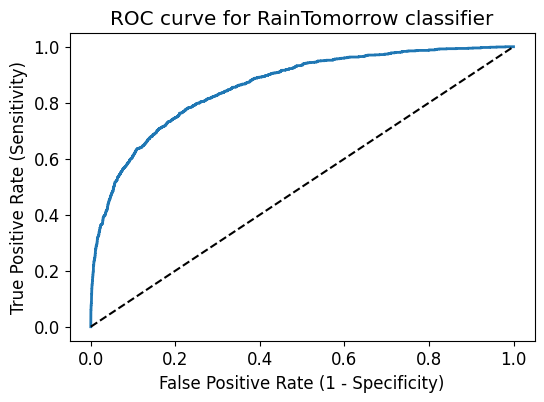

In [446]:
# plot ROC Curve
#ROC curve help us to choose a threshold level that balances sensitivity and specificity 
#for a particular context.

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred1, pos_label = 'Yes')

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, linewidth=2)

plt.plot([0,1], [0,1], 'k--' )

plt.rcParams['font.size'] = 12

plt.title('ROC curve for RainTomorrow classifier')

plt.xlabel('False Positive Rate (1 - Specificity)')

plt.ylabel('True Positive Rate (Sensitivity)')

plt.show()


In [ ]:
#ROC AUC stands for Receiver Operating Characteristic - Area Under Curve. 
#It is a technique to compare classifier performance. 
#In this technique, we measure the area under the curve (AUC). 
#A perfect classifier will have a ROC AUC equal to 1, whereas a purely random classifier 
#will have a ROC AUC equal to 0.5.

#So, ROC AUC is the percentage of the ROC plot that is underneath the curve.

In [447]:
# compute ROC AUC

from sklearn.metrics import roc_auc_score

ROC_AUC = roc_auc_score(y_test, y_pred1)

print('ROC AUC : {:.4f}'.format(ROC_AUC))

ROC AUC : 0.8589


In [449]:
#ROC AUC is a single number summary of classifier performance. 
#The higher the value, the better the classifier.

#ROC AUC of our model approaches towards 1. 
#So, we can conclude that our classifier does a good job in predicting whether it will rain tomorrow or not.

In [450]:
# calculate cross-validated ROC AUC 

from sklearn.model_selection import cross_val_score

Cross_validated_ROC_AUC = cross_val_score(logreg, X_train, y_train, cv=5, scoring='roc_auc').mean()

print('Cross validated ROC AUC : {:.4f}'.format(Cross_validated_ROC_AUC))

Cross validated ROC AUC : 0.8562


In [451]:
#I will discuss 3 techniques which are used in practice for performance improvement.
#These are recursive feature elimination, k-fold cross validation and 
#hyperparameter optimization using GridSearchCV.

In [452]:
#Recursive feature elimination (RFE) is a feature selection technique that helps us to select 
#best features from the given number of features. At first, the model is built on all the given features. 
#Then, it removes the least useful predictor and build the model again. This process is repeated until all
#the unimportant features are removed from the model.

#Recursive Feature Elimination with Cross-Validated (RFECV) feature selection technique 
#selects the best subset of features for the estimator by removing 0 to N features 
#iteratively using recursive feature elimination. Then it selects the 
#best subset based on the accuracy or cross-validation score or roc-auc of the model.
#Recursive feature elimination technique eliminates n features from a model by fitting the 
#model multiple times and at each step, removing the weakest features.

#I will use this technique to select best features from this model.

In [453]:
from sklearn.feature_selection import RFECV

rfecv = RFECV(estimator=logreg, step=1, cv=5, scoring='accuracy')

rfecv = rfecv.fit(X_train, y_train)

In [454]:
print("Optimal number of features : %d" % rfecv.n_features_)

Optimal number of features : 18


In [455]:
# transform the training data

X_train_rfecv = rfecv.transform(X_train)


# train classifier

logreg.fit(X_train_rfecv, y_train)

LogisticRegression(random_state=0, solver='liblinear')

In [456]:
# test classifier on test data

X_test_rfecv = rfecv.transform(X_test)

y_pred_rfecv = logreg.predict(X_test_rfecv)

In [457]:
# print mean accuracy on transformed test data and labels

print ("Classifier score: {:.4f}".format(logreg.score(X_test_rfecv,y_test)))

Classifier score: 0.8394


In [458]:
#Our original model accuracy score is Model accuracy score: 0.8420 
#whereas accuracy score after RFECV is 0.8394. 
#So, we can obtain approximately similar accuracy but with reduced or optimal set of features.

In [459]:
#Confusion-matrix revisited
#I will again plot the confusion-matrix for this model to get an idea of errors our model is making.

from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test, y_pred_rfecv)

print('Confusion matrix\n\n', cm1)

print('\nTrue Positives(TP1) = ', cm1[0,0])

print('\nTrue Negatives(TN1) = ', cm1[1,1])

print('\nFalse Positives(FP1) = ', cm1[0,1])

print('\nFalse Negatives(FN1) = ', cm1[1,0])

Confusion matrix

 [[3656  204]
 [ 599  541]]

True Positives(TP1) =  3656

True Negatives(TN1) =  541

False Positives(FP1) =  204

False Negatives(FN1) =  599


In [ ]:
#In original model-
#True Positives(TP) =  3659

#True Negatives(TN) =  551

#False Positives(FP) =  201

#False Negatives(FN) =  589

#We can see that in the original model, we have FP = 201 whereas FP1 = 204. 
#So, we get approximately same number of false positives. Also, FN = 589 whereas FN1 = 599. 
#So, we get slightly higher false negatives.

In [460]:
# Applying 10-Fold Cross Validation

from sklearn.model_selection import cross_val_score

scores = cross_val_score(logreg, X_train, y_train, cv = 5, scoring='accuracy')

print('Cross-validation scores:{}'.format(scores))

Cross-validation scores:[0.84275 0.839   0.842   0.84025 0.84575]


In [461]:
#We can summarize the cross-validation accuracy by calculating its mean.

# compute Average cross-validation score

print('Average cross-validation score: {:.4f}'.format(scores.mean()))

Average cross-validation score: 0.8420


In [462]:
#Our, original model score is found to be 0.8448. The average cross-validation score is 0.8420. 
#So, we can conclude that cross-validation does not result in performance improvement.

In [463]:
from sklearn.model_selection import GridSearchCV


parameters = [{'penalty':['l1','l2']}, 
              {'C':[1, 10, 100, 1000]}]



grid_search = GridSearchCV(estimator = logreg,  
                           param_grid = parameters,
                           scoring = 'accuracy',
                           cv = 5,
                           verbose=0)


grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=LogisticRegression(random_state=0, solver='liblinear'),
             param_grid=[{'penalty': ['l1', 'l2']}, {'C': [1, 10, 100, 1000]}],
             scoring='accuracy')

In [464]:
# examine the best model

# best score achieved during the GridSearchCV
print('GridSearch CV best score : {:.4f}\n\n'.format(grid_search.best_score_))

# print parameters that give the best results
print('Parameters that give the best results :','\n\n', (grid_search.best_params_))

# print estimator that was chosen by the GridSearch
print('\n\nEstimator that was chosen by the search :','\n\n', (grid_search.best_estimator_))

GridSearch CV best score : 0.8436


Parameters that give the best results : 

 {'C': 10}


Estimator that was chosen by the search : 

 LogisticRegression(C=10, random_state=0, solver='liblinear')


In [465]:
# calculate GridSearch CV score on test set

print('GridSearch CV score on test set: {0:0.4f}'.format(grid_search.score(X_test, y_test)))

GridSearch CV score on test set: 0.8444


In [ ]:
#Our original model test accuracy is 0.8420 while GridSearch CV score is 0.8444
#We can see that GridSearch CV improve the performance for this particular model.